<a href="https://colab.research.google.com/github/rf-pharma/project-superstore-datasets-/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
#load the data
url="https://github.com/rf-pharma/project-superstore-datasets-/raw/refs/heads/main/Sample%20store.csv"
df = pd.read_csv(url, encoding='latin1')
# show the first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# check data typr and structure
df.info()
#statistics summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4578 entries, 0 to 4577
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         4578 non-null   int64  
 1   Order ID       4578 non-null   object 
 2   Order Date     4578 non-null   object 
 3   Ship Date      4578 non-null   object 
 4   Ship Mode      4578 non-null   object 
 5   Customer ID    4578 non-null   object 
 6   Customer Name  4578 non-null   object 
 7   Segment        4578 non-null   object 
 8   Country        4578 non-null   object 
 9   City           4578 non-null   object 
 10  State          4578 non-null   object 
 11  Postal Code    4578 non-null   int64  
 12  Region         4578 non-null   object 
 13  Product ID     4578 non-null   object 
 14  Category       4578 non-null   object 
 15  Sub-Category   4578 non-null   object 
 16  Product Name   4578 non-null   object 
 17  Sales          4578 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,4578.000000,4578.000000,4578.000000,4578.000000,4578.000000,4578.000000
mean,2289.500000,54879.289646,232.425959,3.802315,0.156686,26.212476
std,1321.699096,31767.037835,650.125232,2.245579,0.206231,211.017604
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-3839.990400
25%,1145.250000,22920.750000,16.768000,2.000000,0.000000,1.747800
50%,2289.500000,55122.000000,52.728000,3.000000,0.200000,8.713900
75%,3433.750000,90004.000000,213.394000,5.000000,0.200000,28.847950
max,4578.000000,99207.000000,22638.480000,14.000000,0.800000,5039.985600


In [ ]:
#identify missing value
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


There is no missing value in the data set

In [ ]:
# Convert Order Date and Ship Date to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Verify the change
print(df.dtypes[['Order Date', 'Ship Date']])

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [ ]:
# Extract Month and Year from Order Date
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

# Create a new column: Profit Margin
df['Profit Margin'] = df['Profit'] / df['Sales']

# Verify the new columns
print(df[['Sales', 'Profit', 'Profit Margin']].head())

      Sales    Profit  Profit Margin
0  261.9600   41.9136         0.1600
1  731.9400  219.5820         0.3000
2   14.6200    6.8714         0.4700
3  957.5775 -383.0310        -0.4000
4   22.3680    2.5164         0.1125


In [ ]:
# total sales by category
s_by_c=df.groupby('Category')['Sales'].sum()
print(s_by_c)

Category
Furniture          330574.6899
Office Supplies    326531.8950
Technology         406939.4570
Name: Sales, dtype: float64


In [ ]:
#total profit by region
p_by_r=df.groupby('Region')['Profit'].sum()
print(p_by_r)

Region
Central    15016.8592
East       40471.4019
South      21377.3504
West       43135.1023
Name: Profit, dtype: float64


In [ ]:
#top 5 customers by sales
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head()

,Sales
Customer Name,
Sean Miller,24195.646
Tom Ashbrook,13716.458
Ken Lonsdale,12645.907
Hunter Lopez,12432.388
Sanjit Chand,12037.794


In [ ]:
# monthly sales trends
monthly_sales_trends=df.groupby(['Year', 'Month'])['Sales'].sum()
print(monthly_sales_trends)

Year  Month
2014  1         6221.2980
      2         1362.5060
      3        33887.9310
      4        13391.8550
      5        11089.2350
      6        24693.5356
      7        21470.4440
      8        15682.8285
      9        46543.1318
      10       15259.9610
      11       41441.7980
      12       35121.7485
2015  1         6350.7880
      2         4390.1950
      3        21112.0690
      4        15141.1470
      5         6592.7280
      6         8496.5730
      7        22436.9230
      8        22149.9320
      9        30294.9180
      10       15318.3665
      11       26074.4503
      12       35779.2892
2016  1         5824.5750
      2         5880.8100
      3        22852.1520
      4        23422.7920
      5        25993.0300
      6        15271.6600
      7        21959.7630
      8        14315.7518
      9        32821.5979
      10       12453.1440
      11       28481.3858
      12       34062.3790
2017  1        16196.8670
      2         7832.3420


In [ ]:
#sales by category and region
piv1=df.pivot_table(index='Category', columns='Region', values='Sales', aggfunc='sum')
print(piv1)

Region              Central        East      South         West
Category                                                       
Furniture        78854.0934   84891.987  48498.126  118330.4835
Office Supplies  69197.3890   97825.970  64616.978   94891.5580
Technology       82936.1420  124115.622  83425.260  116462.4330


In [ ]:
#sales trends by segment over time
piv2=df.pivot_table(index='Order Date', columns='Segment', values='Sales', aggfunc='sum')
print(piv2)

Segment     Consumer  Corporate  Home Office
Order Date                                  
2014-01-04       NaN        NaN      288.060
2014-01-05   19.5360        NaN          NaN
2014-01-09   40.5440        NaN          NaN
2014-01-10       NaN     54.830          NaN
2014-01-11    9.9400        NaN          NaN
...              ...        ...          ...
2017-12-26   44.7500        NaN        3.132
2017-12-27       NaN    177.636          NaN
2017-12-28  240.5448    733.240       64.784
2017-12-29  701.9740    209.700          NaN
2017-12-30  466.8420     34.624      209.300

[988 rows x 3 columns]


In [ ]:
#profit by sub_category
piv3=df.pivot_table(index='Sub-Category', columns='Profit', values='Sales', aggfunc='sum')

print(piv3)

Profit        -3839.9904  -3399.9800  -2639.9912  -1850.9464  -1811.0784  \
Sub-Category                                                               
Accessories          NaN         NaN         NaN         NaN         NaN   
Appliances           NaN         NaN         NaN         NaN         NaN   
Art                  NaN         NaN         NaN         NaN         NaN   
Binders              NaN         NaN         NaN    1088.792         NaN   
Bookcases            NaN         NaN         NaN         NaN         NaN   
Chairs               NaN         NaN         NaN         NaN         NaN   
Copiers              NaN         NaN         NaN         NaN         NaN   
Envelopes            NaN         NaN         NaN         NaN         NaN   
Fasteners            NaN         NaN         NaN         NaN         NaN   
Furnishings          NaN         NaN         NaN         NaN         NaN   
Labels               NaN         NaN         NaN         NaN         NaN   
Machines    

In [ ]:
# Split into two DataFrames (e.g., separate sales data and product info)
df_sales = df[['Order ID', 'Sales', 'Profit', 'Product ID']]
df_products = df[['Product ID', 'Category', 'Sub-Category']].drop_duplicates()
print(df_sales.head())
print(df_products.head())

         Order ID     Sales    Profit       Product ID
0  CA-2016-152156  261.9600   41.9136  FUR-BO-10001798
1  CA-2016-152156  731.9400  219.5820  FUR-CH-10000454
2  CA-2016-138688   14.6200    6.8714  OFF-LA-10000240
3  US-2015-108966  957.5775 -383.0310  FUR-TA-10000577
4  US-2015-108966   22.3680    2.5164  OFF-ST-10000760
        Product ID         Category Sub-Category
0  FUR-BO-10001798        Furniture    Bookcases
1  FUR-CH-10000454        Furniture       Chairs
2  OFF-LA-10000240  Office Supplies       Labels
3  FUR-TA-10000577        Furniture       Tables
4  OFF-ST-10000760  Office Supplies      Storage


In [ ]:
# Merge them back and check
df_merged = pd.merge(df_sales, df_products, on='Product ID', how='left')
print(df_merged.head())

         Order ID     Sales    Profit       Product ID         Category  \
0  CA-2016-152156  261.9600   41.9136  FUR-BO-10001798        Furniture   
1  CA-2016-152156  731.9400  219.5820  FUR-CH-10000454        Furniture   
2  CA-2016-138688   14.6200    6.8714  OFF-LA-10000240  Office Supplies   
3  US-2015-108966  957.5775 -383.0310  FUR-TA-10000577        Furniture   
4  US-2015-108966   22.3680    2.5164  OFF-ST-10000760  Office Supplies   

  Sub-Category  
0    Bookcases  
1       Chairs  
2       Labels  
3       Tables  
4      Storage  


In [ ]:
import matplotlib.pyplot as plt


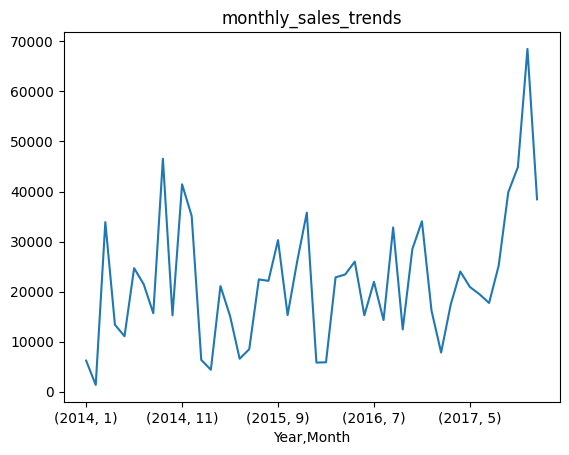

In [ ]:
monthly_sales_trends.plot()
plt.title("monthly_sales_trends")
plt.show()

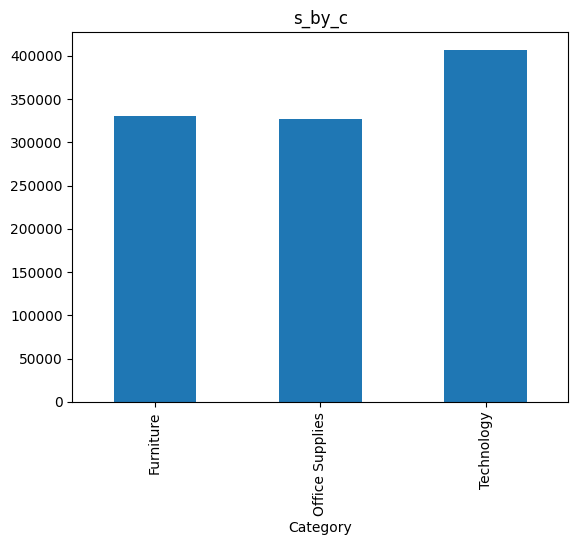

In [ ]:
s_by_c.plot(kind='bar')
plt.title("s_by_c")
plt.show()

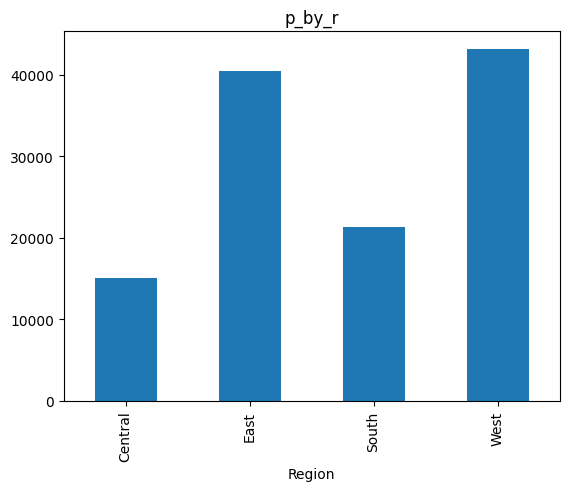

In [ ]:
p_by_r.plot(kind='bar')
plt.title("p_by_r")
plt.show()

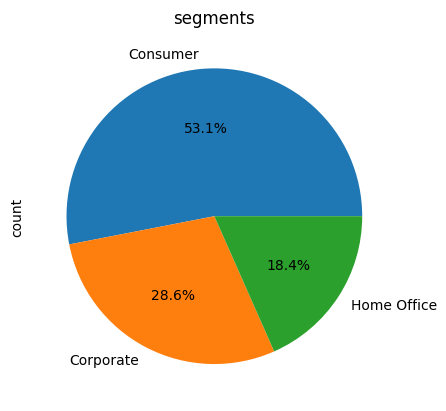

In [ ]:
segments=df['Segment'].value_counts()
segments.plot(kind='pie', autopct='%1.1f%%')
plt.title("segments")
plt.show()

In [ ]:
# the most profitable catagory
most_profitable_category = df.groupby('Category')['Profit'].sum()
print(most_profitable_category)

print("Most Profitable Category:", most_profitable_category.idxmax())

Category
Furniture           7910.0708
Office Supplies    54078.2733
Technology         58012.3697
Name: Profit, dtype: float64
Most Profitable Category: Technology


Technology is the most profitable catagory

In [ ]:
#least performing region
least_region = df.groupby('Region')['Profit'].sum()
print(least_region)

print("Least Performing Region:", least_region.idxmin())

Region
Central    15016.8592
East       40471.4019
South      21377.3504
West       43135.1023
Name: Profit, dtype: float64
Least Performing Region: Central


central is least performing region

In [ ]:
correlation = df['Sales'].corr(df['Profit'])
print("Correlation between Sales and Profit:", correlation)

Correlation between Sales and Profit: 0.3176950267729399


the corr value 0.3 indicates a weak positivr relation ship between profit and sales ,means profit tends to increase with sale but not consistently

In [ ]:
trend = df.groupby(['Year', 'Month'])['Sales'].sum()
print(trend)

Year  Month
2014  1         6221.2980
      2         1362.5060
      3        33887.9310
      4        13391.8550
      5        11089.2350
      6        24693.5356
      7        21470.4440
      8        15682.8285
      9        46543.1318
      10       15259.9610
      11       41441.7980
      12       35121.7485
2015  1         6350.7880
      2         4390.1950
      3        21112.0690
      4        15141.1470
      5         6592.7280
      6         8496.5730
      7        22436.9230
      8        22149.9320
      9        30294.9180
      10       15318.3665
      11       26074.4503
      12       35779.2892
2016  1         5824.5750
      2         5880.8100
      3        22852.1520
      4        23422.7920
      5        25993.0300
      6        15271.6600
      7        21959.7630
      8        14315.7518
      9        32821.5979
      10       12453.1440
      11       28481.3858
      12       34062.3790
2017  1        16196.8670
      2         7832.3420




* Sales increase toward end of year (Nov–Dec)


* Seasonal patterns exist



* Some months show drops (low demand periods)



